In [1]:
############################################################
## 1. Import Libraries
############################################################

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

pd.options.display.float_format = '{:,.2f}'.format

In [4]:
############################################################
## 2. Load Dataset 
############################################################

excel_path = "Attendance-Sheet-2022-2023.xlsx"

# Read all sheets (row 2 as header)
all_sheets = pd.read_excel(excel_path, sheet_name=None, header=1)

print("Available sheets:", list(all_sheets.keys()))

# Use all sheets EXCEPT the one with "key" in its name as month sheets
month_sheet_names = [name for name in all_sheets.keys() if "key" not in name.lower()]
print("Month sheets used for analysis:", month_sheet_names)

df_list = []
for sheet_name in month_sheet_names:
    df_m = all_sheets[sheet_name].copy()

    # Clean column names
    df_m.columns = df_m.columns.str.strip()

    # DROP duplicated columns (keeps the first occurrence)
    df_m = df_m.loc[:, ~df_m.columns.duplicated()]

    # Add month label
    df_m["Month"] = sheet_name

    df_list.append(df_m)

# Now concat safely
df_raw = pd.concat(df_list, ignore_index=True)

df_raw.head()

C:\Users\baymax\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\baymax\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


Available sheets: ['June 2022', 'May 2022', 'Apr 2022', 'Attendance Key ']
Month sheets used for analysis: ['June 2022', 'May 2022', 'Apr 2022']


C:\Users\baymax\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


,Employee Code,Name,NaN,2022-06-01 00:00:00.1,TPD,P,WFH,PL,SL,BL,FFL,BRL,LWP,WO,HO,ML,Month
0,Atq -406,Thanos Thakur,P,NaN,13.00,13.00,0.00,0.00,0.00,0,0,0,0.00,8,0,0.00,June 2022
1,Atq -462,Jarvis Singh,P,NaN,13.00,13.00,0.00,0.00,0.00,0,0,0,0.00,8,0,0.00,June 2022
2,Atq -411,Nevaeh Waller,P,NaN,13.00,13.00,0.00,0.00,0.00,0,0,0,0.00,8,0,0.00,June 2022
3,Atq -398,Bo Cordova,SL,NaN,19.00,7.00,12.00,0.00,1.00,0,0,0,0.00,8,0,0.00,June 2022
4,Atq -438,Mekhi Singleton,P,NaN,12.00,12.00,0.00,1.00,0.00,0,0,0,0.00,8,0,0.00,June 2022


In [5]:
############################################################
## 3. Data Cleaning 
############################################################

# Start from df_raw created in step 2
df = df_raw.dropna(how="all").copy()

# Clean column names
df.columns = df.columns.astype(str).str.strip()

# Drop any unnamed / blank columns (like the NaN one you see)
df = df.loc[:, ~df.columns.str.contains("^Unnamed", na=False)]

# Rename coded summary columns to readable names
rename_summary = {
    "TPD": "Total Present Days",
    "P": "Present",
    "WFH": "Work from home",
    "PL": "Paid Leave",
    "SL": "Sick Leave",
    "BL": "Birthday Leave",
    "FFL": "Floting festival leave",
    "BRL": "Bereavement Leave",
    "LWP": "Leave without pay",
    "WO": "Weekly Off",
    "HO": "Holidays Off",
    "ML": "Menstrual Leave",
}
df = df.rename(columns={k: v for k, v in rename_summary.items() if k in df.columns})

# Make sure numeric summary columns are numeric
num_cols = [
    "Total Present Days", "Present", "Work from home", "Paid Leave", "Sick Leave",
    "Birthday Leave", "Floting festival leave", "Bereavement Leave",
    "Leave without pay", "Weekly Off", "Holidays Off", "Menstrual Leave"
]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Identify day columns: everything between Name and Total Present Days
first_day_col_index = df.columns.get_loc("Name") + 1
last_day_col_index = df.columns.get_loc("Total Present Days")
day_cols = df.columns[first_day_col_index:last_day_col_index]

# Rename day columns to Day_1, Day_2, ...
new_day_names = [f"Day_{i+1}" for i in range(len(day_cols))]
rename_map = dict(zip(day_cols, new_day_names))
df = df.rename(columns=rename_map)

day_cols = new_day_names  # update list

df[["Employee Code", "Name", "Month"] + list(day_cols) + ["Total Present Days"]].head()

,Employee Code,Name,Month,Day_1,Day_2,Total Present Days
0,Atq -406,Thanos Thakur,June 2022,P,NaN,13.00
1,Atq -462,Jarvis Singh,June 2022,P,NaN,13.00
2,Atq -411,Nevaeh Waller,June 2022,P,NaN,13.00
3,Atq -398,Bo Cordova,June 2022,SL,NaN,19.00
4,Atq -438,Mekhi Singleton,June 2022,P,NaN,12.00


In [6]:
############################################################
## 4. Feature Engineering
############################################################

# Attendance = Present + Work from home
attendance_cols = ["Present", "Work from home"]

# Leave types (you can adjust later if HR policy changes)
leave_cols = [
    "Paid Leave", "Sick Leave", "Birthday Leave", "Floting festival leave",
    "Bereavement Leave", "Menstrual Leave", "Leave without pay"
]

# Keep only existing columns
attendance_cols = [c for c in attendance_cols if c in df.columns]
leave_cols = [c for c in leave_cols if c in df.columns]

# Working days = attendance + all leave types (exclude weekly off & holidays off)
df["working_days"] = df[attendance_cols + leave_cols].sum(axis=1)

# Total leave days
df["total_leaves"] = df[leave_cols].sum(axis=1)

# Attendance days (P + WFH)
df["attendance_days"] = df[attendance_cols].sum(axis=1)

# Attendance rate per employee
df["attendance_rate"] = np.where(
    df["working_days"] > 0,
    df["attendance_days"] / df["working_days"],
    np.nan
)

# WFH % of attendance
if "Work from home" in df.columns:
    df["wfh_pct_of_attendance"] = np.where(
        df["attendance_days"] > 0,
        df["Work from home"] / df["attendance_days"],
        0
    )
else:
    df["wfh_pct_of_attendance"] = 0

# Absenteeism risk score (simple weighted formula you can tweak)
df["absenteeism_score"] = (
    df.get("Leave without pay", 0) * 2 +
    df.get("Sick Leave", 0) * 1.5 +
    df["total_leaves"]
)

df[[
    "Employee Code", "Name", "Month", "working_days", "attendance_days",
    "total_leaves", "attendance_rate", "wfh_pct_of_attendance",
    "absenteeism_score"
]].head()

,Employee Code,Name,Month,working_days,attendance_days,total_leaves,attendance_rate,wfh_pct_of_attendance,absenteeism_score
0,Atq -406,Thanos Thakur,June 2022,13.00,13.00,0.00,1.00,0.00,0.00
1,Atq -462,Jarvis Singh,June 2022,13.00,13.00,0.00,1.00,0.00,0.00
2,Atq -411,Nevaeh Waller,June 2022,13.00,13.00,0.00,1.00,0.00,0.00
3,Atq -398,Bo Cordova,June 2022,20.00,19.00,1.00,0.95,0.63,2.50
4,Atq -438,Mekhi Singleton,June 2022,13.00,12.00,1.00,0.92,0.00,1.00


In [7]:
############################################################
## 5. Exploratory Data Analysis
############################################################

# Quick overview
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee Code,247,74,Atq -375,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,247,99,Thanos Thakur,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_1,231,10,P,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_2,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Present Days,247.00,NaN,NaN,NaN,16.68,4.72,2.00,13.00,19.00,21.00,22.00
Present,247.00,NaN,NaN,NaN,14.85,5.81,0.00,12.00,16.00,20.00,22.00
Work from home,247.00,NaN,NaN,NaN,1.83,4.05,0.00,0.00,0.00,1.75,22.00
Paid Leave,247.00,NaN,NaN,NaN,0.65,1.47,0.00,0.00,0.00,1.00,15.00
Sick Leave,247.00,NaN,NaN,NaN,0.19,0.55,0.00,0.00,0.00,0.00,5.00
Birthday Leave,247.00,NaN,NaN,NaN,0.02,0.13,0.00,0.00,0.00,0.00,1.00


In [8]:
# Long format table: one row per employee per day per month
daily_long = df.melt(
    id_vars=["Employee Code", "Name", "Month"],
    value_vars=day_cols,
    var_name="Day",
    value_name="Status"
)

daily_long["Status"] = daily_long["Status"].astype(str).str.strip()

daily_long.head()

,Employee Code,Name,Month,Day,Status
0,Atq -406,Thanos Thakur,June 2022,Day_1,P
1,Atq -462,Jarvis Singh,June 2022,Day_1,P
2,Atq -411,Nevaeh Waller,June 2022,Day_1,P
3,Atq -398,Bo Cordova,June 2022,Day_1,SL
4,Atq -438,Mekhi Singleton,June 2022,Day_1,P


In [9]:
############################################################
## Dashboard – Workforce KPIs
############################################################

# Overall aggregates
total_employees = df["Employee Code"].nunique()

total_working_days = df["working_days"].sum()
total_attendance_days = df["attendance_days"].sum()
total_leave_days = df["total_leaves"].sum()

overall_attendance_rate = (
    total_attendance_days / total_working_days
    if total_working_days > 0 else np.nan
)

total_wfh_days = df.get("Work from home", pd.Series(0, index=df.index)).sum()
total_present_office_days = df.get("Present", pd.Series(0, index=df.index)).sum()
total_attendance_all = total_wfh_days + total_present_office_days

wfh_pct_overall = (
    total_wfh_days / total_attendance_all
    if total_attendance_all > 0 else 0
)

print(f"Total Employees: {total_employees}")
print(f"Overall Attendance Rate: {overall_attendance_rate:.2%}")
print(f"Total Working Days (all employees): {total_working_days:.0f}")
print(f"Total Leave Days (all employees): {total_leave_days:.0f}")
print(f"WFH % of Attendance: {wfh_pct_overall:.2%}")

Total Employees: 74
Overall Attendance Rate: 92.50%
Total Working Days (all employees): 4454
Total Leave Days (all employees): 334
WFH % of Attendance: 10.99%


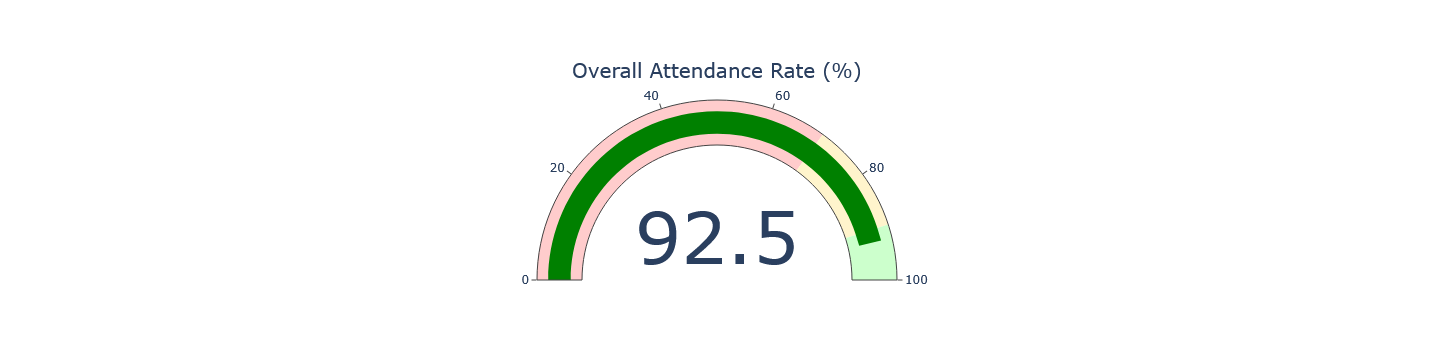

In [10]:
# Attendance rate gauge
fig_gauge = go.Figure(go.Indicator(
    mode="gauge+number",
    value=overall_attendance_rate * 100 if pd.notnull(overall_attendance_rate) else 0,
    title={"text": "Overall Attendance Rate (%)"},
    gauge={
        "axis": {"range": [0, 100]},
        "bar": {"color": "green"},
        "steps": [
            {"range": [0, 70], "color": "#ffcccc"},
            {"range": [70, 90], "color": "#fff4cc"},
            {"range": [90, 100], "color": "#ccffcc"},
        ],
    },
))
fig_gauge.show()

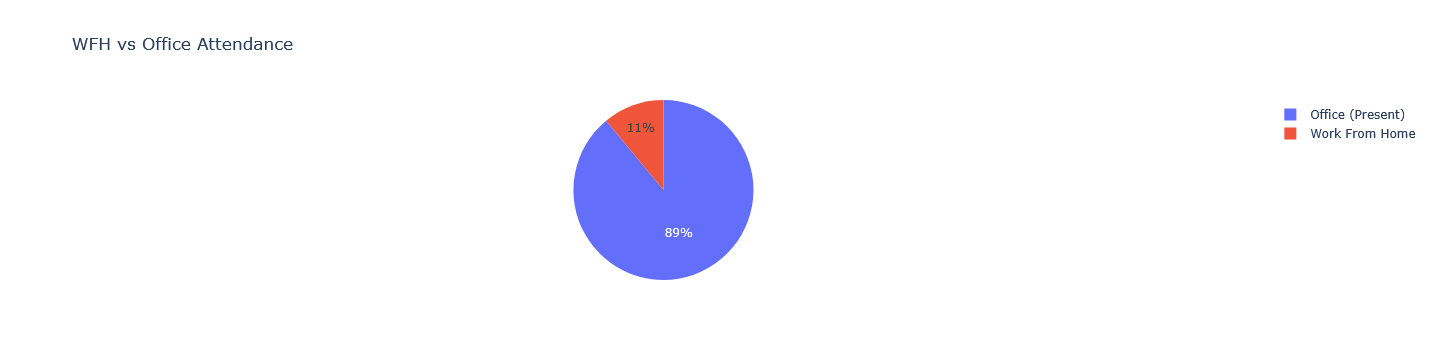

In [11]:
# Pie chart: WFH vs Office
kpi_df = pd.DataFrame({
    "Category": ["Office (Present)", "Work From Home"],
    "Days": [total_present_office_days, total_wfh_days]
})

fig_wfh_pie = px.pie(
    kpi_df,
    names="Category",
    values="Days",
    title="WFH vs Office Attendance"
)
fig_wfh_pie.show()

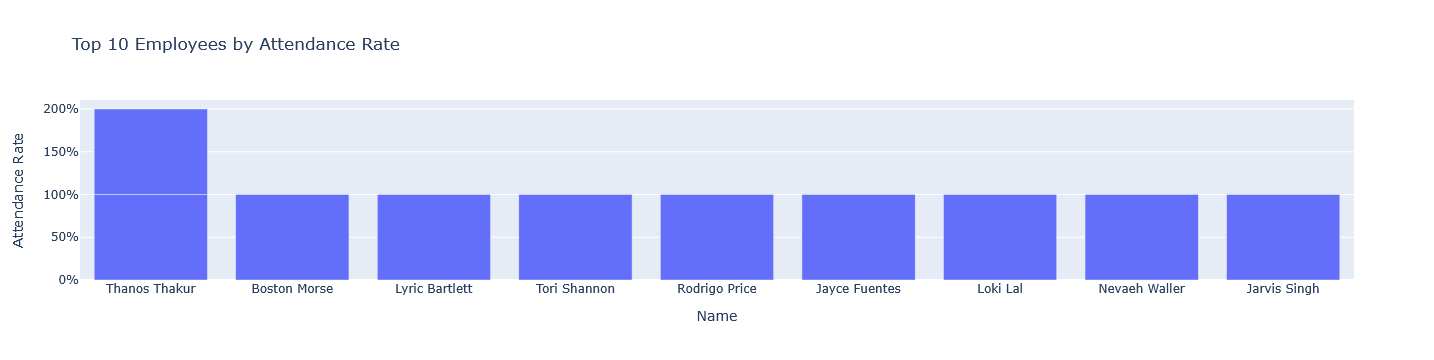

In [12]:
############################################################
## Dashboard – Attendance Analysis (per employee)
############################################################

# Top 10 by attendance rate
top_attendance = df.sort_values("attendance_rate", ascending=False).head(10)

fig_top_att = px.bar(
    top_attendance,
    x="Name",
    y="attendance_rate",
    title="Top 10 Employees by Attendance Rate"
)
fig_top_att.update_yaxes(title="Attendance Rate", tickformat=".0%")
fig_top_att.show()

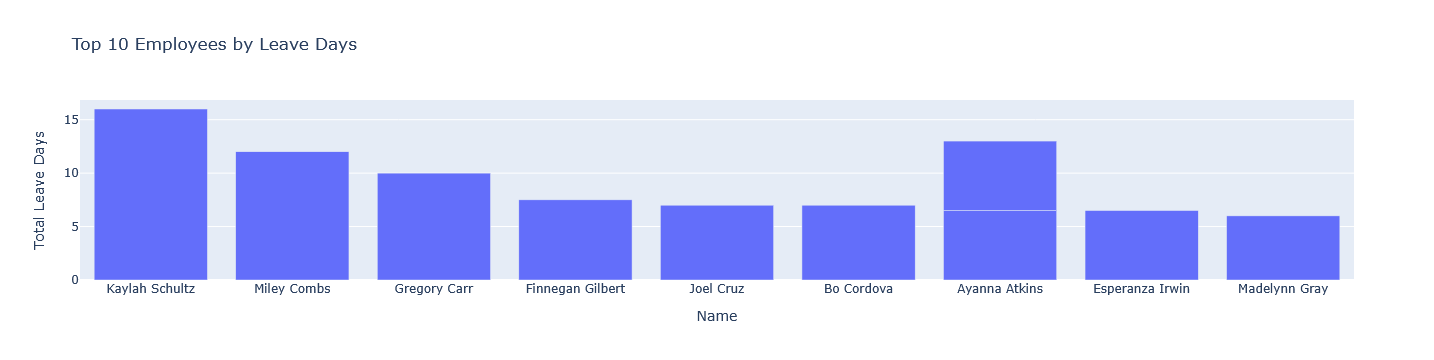

In [13]:
# Top 10 by leave days
most_leaves = df.sort_values("total_leaves", ascending=False).head(10)

fig_leaves = px.bar(
    most_leaves,
    x="Name",
    y="total_leaves",
    title="Top 10 Employees by Leave Days"
)
fig_leaves.update_yaxes(title="Total Leave Days")
fig_leaves.show()

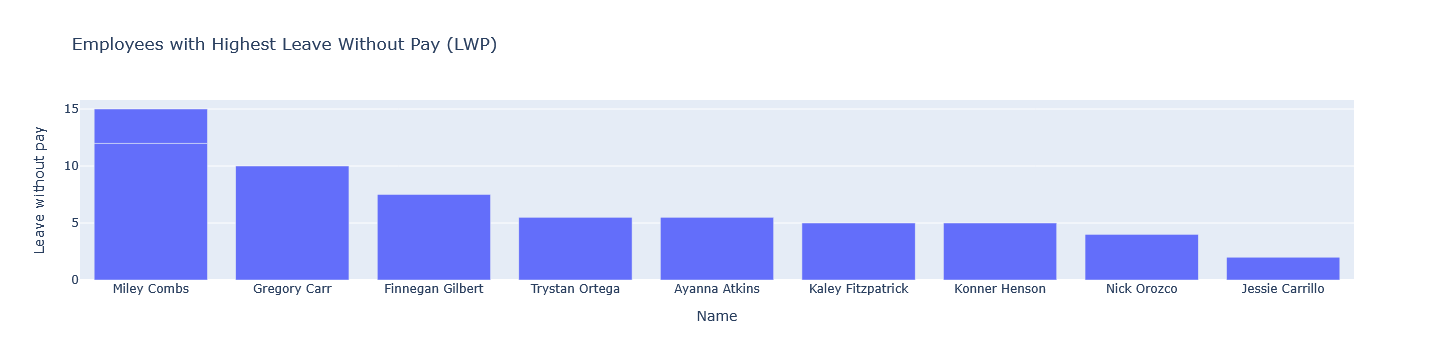

In [14]:
# Employees using LWP (Leave Without Pay)
if "Leave without pay" in df.columns:
    lwp_users = df[df["Leave without pay"] > 0].copy()
    lwp_users = lwp_users.sort_values("Leave without pay", ascending=False)

    fig_lwp = px.bar(
        lwp_users.head(10),
        x="Name",
        y="Leave without pay",
        title="Employees with Highest Leave Without Pay (LWP)"
    )
    fig_lwp.show()

In [15]:
# Table of employee attendance metrics
metrics_cols = [
    "Employee Code", "Name", "Month", "working_days", "attendance_days",
    "total_leaves", "attendance_rate", "wfh_pct_of_attendance",
    "Leave without pay", "absenteeism_score"
]
[col for col in metrics_cols if col in df.columns]

df[metrics_cols].sort_values("attendance_rate", ascending=False).head(20)

,Employee Code,Name,Month,working_days,attendance_days,total_leaves,attendance_rate,wfh_pct_of_attendance,Leave without pay,absenteeism_score
0,Atq -406,Thanos Thakur,June 2022,13.00,13.00,0.00,1.00,0.00,0.00,0.00
187,Atq -334,Boston Morse,Apr 2022,21.00,21.00,0.00,1.00,0.00,0.00,0.00
94,Atq -443,Lyric Bartlett,May 2022,22.00,22.00,0.00,1.00,0.00,0.00,0.00
93,Atq -335,Tori Shannon,May 2022,22.00,22.00,0.00,1.00,0.00,0.00,0.00
195,Atq -423,Rodrigo Price,Apr 2022,21.00,21.00,0.00,1.00,0.00,0.00,0.00
197,Atq -433,Jayce Fuentes,Apr 2022,21.00,21.00,0.00,1.00,0.00,0.00,0.00
89,Atq -441,Loki Lal,May 2022,22.00,22.00,0.00,1.00,0.05,0.00,0.00
85,Atq -411,Nevaeh Waller,May 2022,22.00,22.00,0.00,1.00,0.00,0.00,0.00
84,Atq -462,Jarvis Singh,May 2022,22.00,22.00,0.00,1.00,0.00,0.00,0.00
83,Atq -406,Thanos Thakur,May 2022,22.00,22.00,0.00,1.00,0.00,0.00,0.00


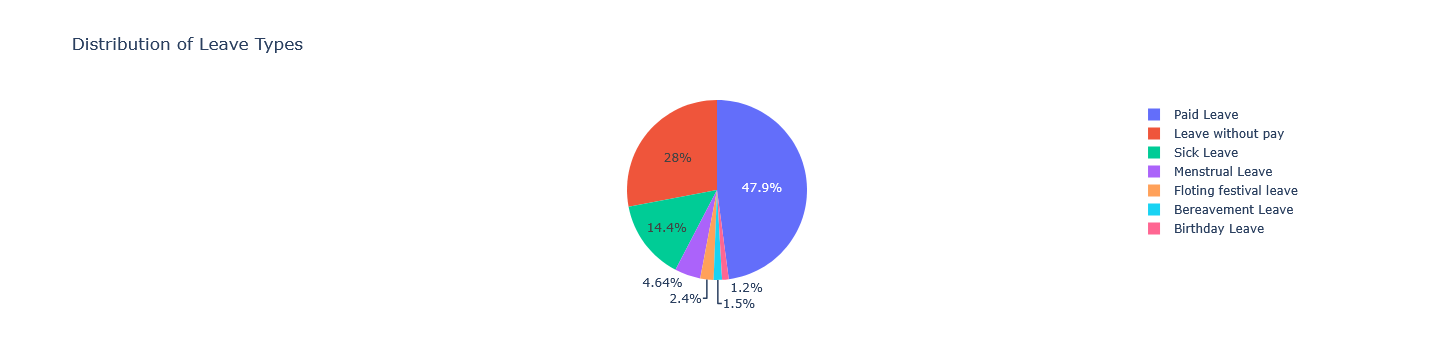

In [16]:
############################################################
## Dashboard – Leave Analysis
############################################################

# Total days for each leave type
leave_totals = df[leave_cols].sum().reset_index()
leave_totals.columns = ["Leave Type", "Days"]
leave_totals = leave_totals[leave_totals["Days"] > 0]

fig_leave_pie = px.pie(
    leave_totals,
    names="Leave Type",
    values="Days",
    title="Distribution of Leave Types"
)
fig_leave_pie.show()

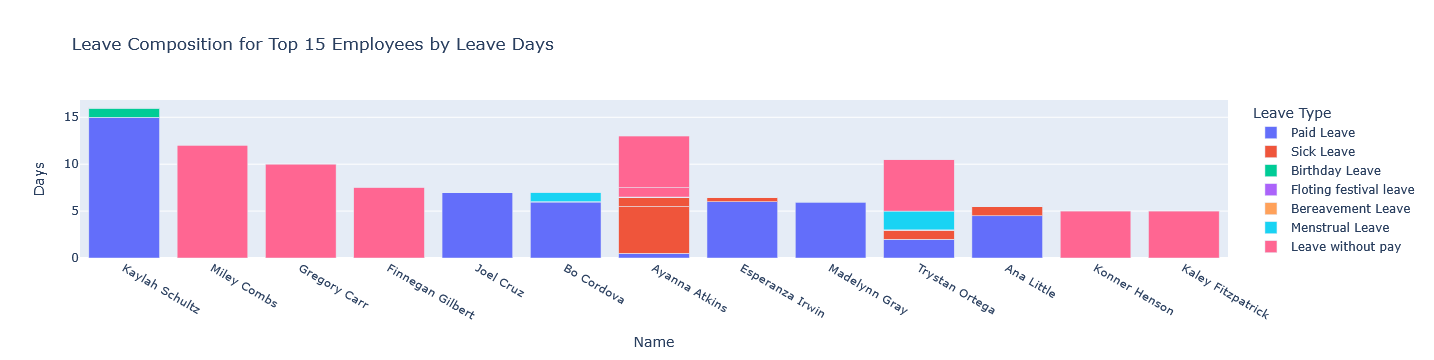

In [17]:
# Stacked bar: leave mix for top N employees by leave days
top_n = 15
top_for_stack = df.sort_values("total_leaves", ascending=False).head(top_n)

fig_leave_stack = px.bar(
    top_for_stack,
    x="Name",
    y=leave_cols,
    title=f"Leave Composition for Top {top_n} Employees by Leave Days",
    labels={"value": "Days", "variable": "Leave Type"}
)
fig_leave_stack.show()

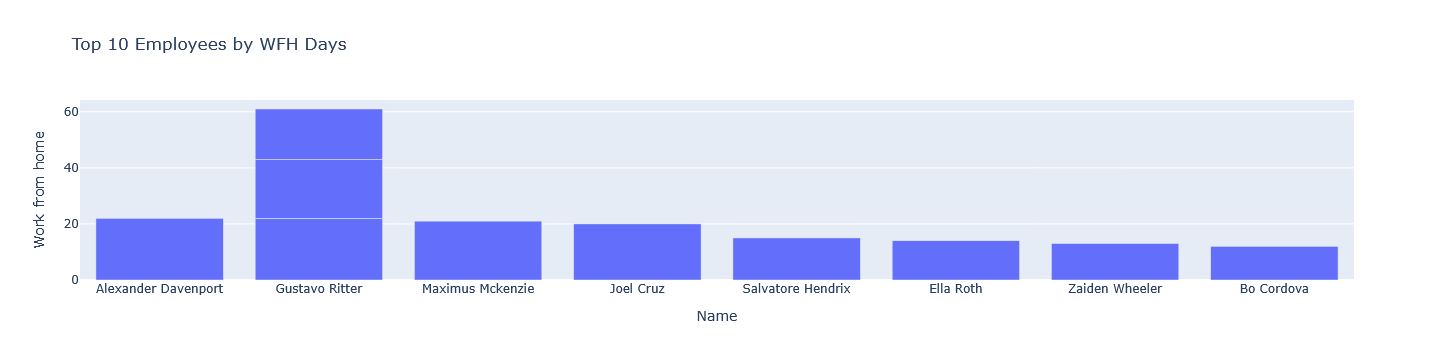

In [18]:
############################################################
## Dashboard – WFH Insights
############################################################

# Employees using WFH most frequently
if "Work from home" in df.columns:
    wfh_top = df.sort_values("Work from home", ascending=False)

    fig_wfh_emp = px.bar(
        wfh_top.head(10),
        x="Name",
        y="Work from home",
        title="Top 10 Employees by WFH Days"
    )
    fig_wfh_emp.show()

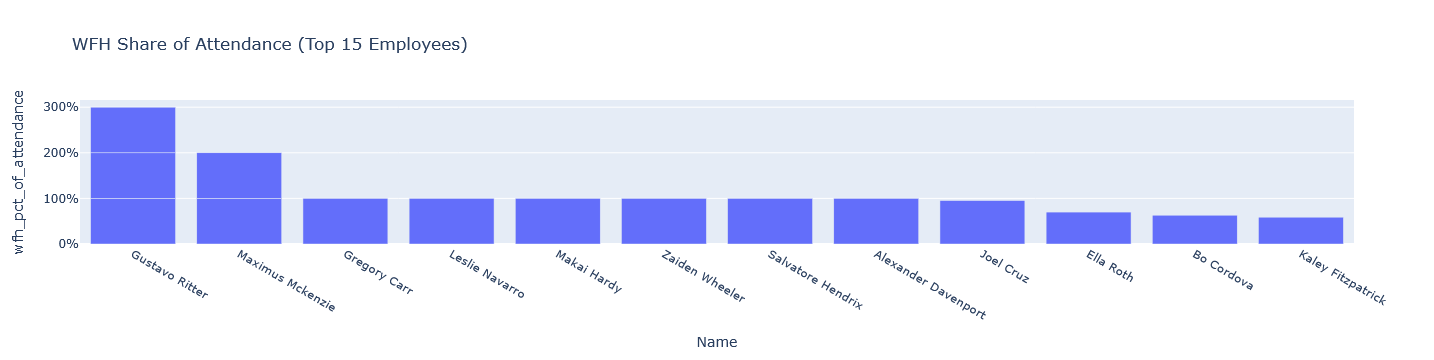

In [19]:
# WFH % of attendance per employee (top 15)
fig_wfh_pct = px.bar(
    df.sort_values("wfh_pct_of_attendance", ascending=False).head(15),
    x="Name",
    y="wfh_pct_of_attendance",
    title="WFH Share of Attendance (Top 15 Employees)"
)
fig_wfh_pct.update_yaxes(tickformat=".0%")
fig_wfh_pct.show()

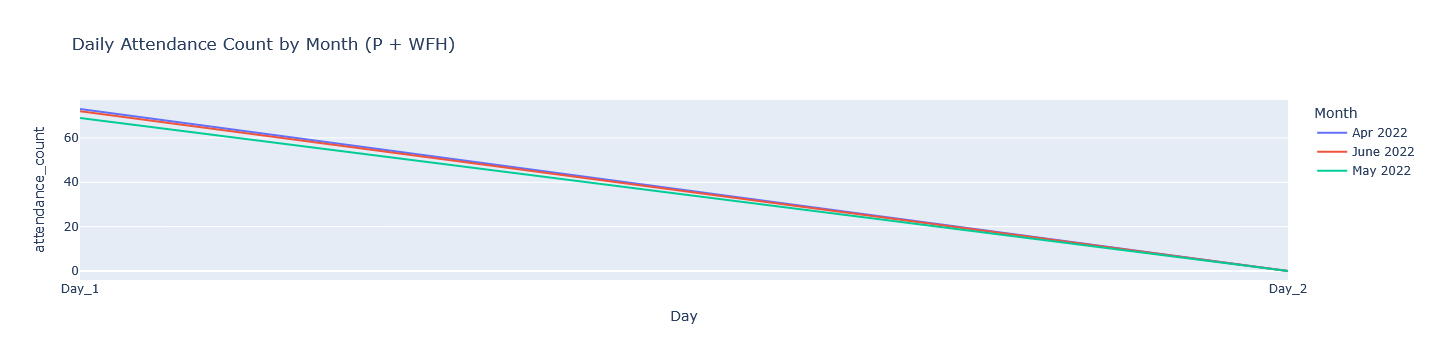

In [20]:
############################################################
## Dashboard – Daily Attendance Trend & Heatmap
############################################################

# Daily attendance count (P + WFH)
attend_statuses = ["P", "WFH"]

daily_attendance = (
    daily_long.assign(
        is_attended = daily_long["Status"].isin(attend_statuses)
    )
    .groupby(["Month", "Day"])["is_attended"]
    .sum()
    .reset_index()
    .rename(columns={"is_attended": "attendance_count"})
)

fig_daily_line = px.line(
    daily_attendance,
    x="Day",
    y="attendance_count",
    color="Month",
    title="Daily Attendance Count by Month (P + WFH)"
)
fig_daily_line.show()

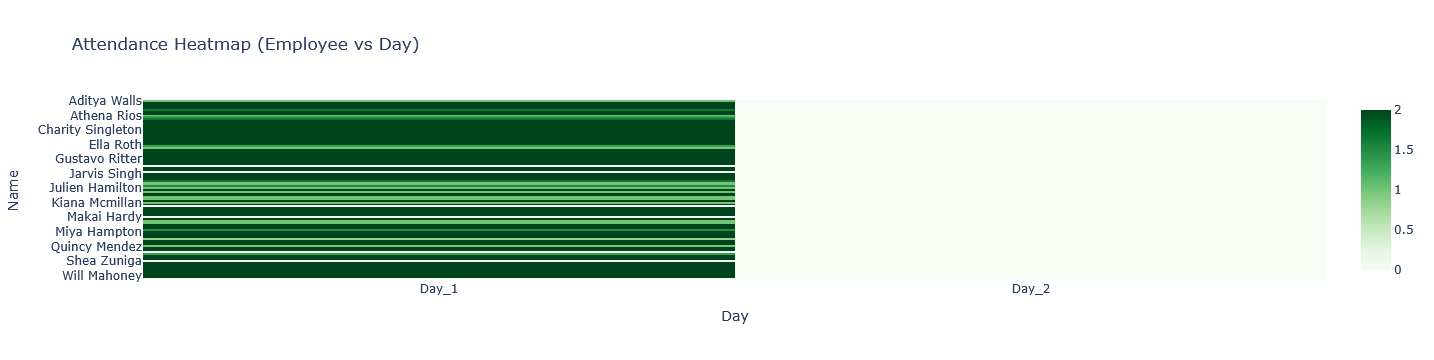

In [21]:
# Heatmap: employee vs day (status score)
status_map = {
    "P": 2,
    "WFH": 2,
    "PL": 1, "SL": 1, "BL": 1, "FFL": 1, "BRL": 1, "ML": 1,
    "LWP": 0.5,
    "WO": 0, "HO": 0
}

daily_long["status_score"] = daily_long["Status"].map(status_map).fillna(0)

heat = daily_long.pivot_table(
    index="Name",
    columns="Day",
    values="status_score",
    aggfunc="mean"
)

fig_heat = px.imshow(
    heat,
    aspect="auto",
    color_continuous_scale="Greens",
    title="Attendance Heatmap (Employee vs Day)"
)
fig_heat.show()

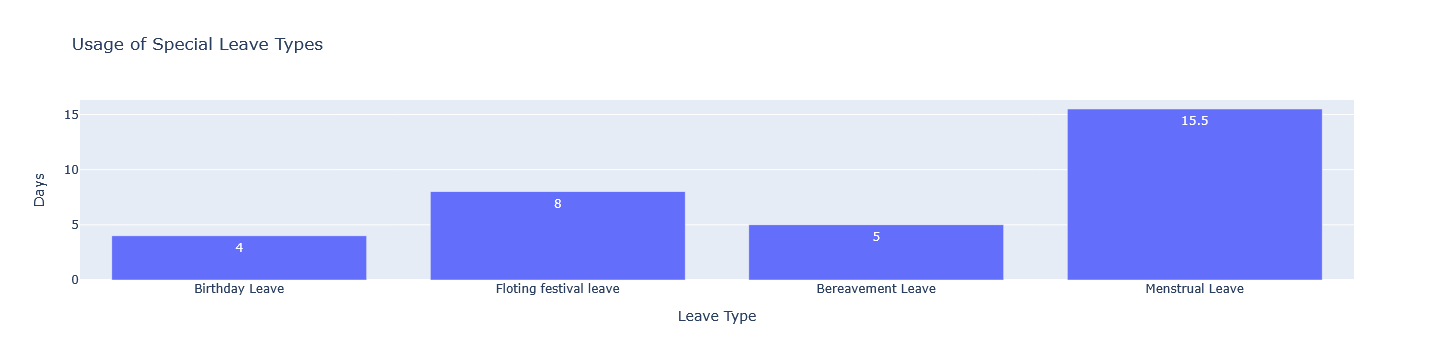

In [22]:
############################################################
## Dashboard – HR Policy Insights (special leaves)
############################################################

special_cols = [
    "Birthday Leave", "Floting festival leave",
    "Bereavement Leave", "Menstrual Leave"
]
special_cols = [c for c in special_cols if c in df.columns]

if special_cols:
    special_usage = df[special_cols].sum().reset_index()
    special_usage.columns = ["Leave Type", "Days"]

    fig_special = px.bar(
        special_usage,
        x="Leave Type",
        y="Days",
        title="Usage of Special Leave Types",
        text="Days"
    )
    fig_special.show()

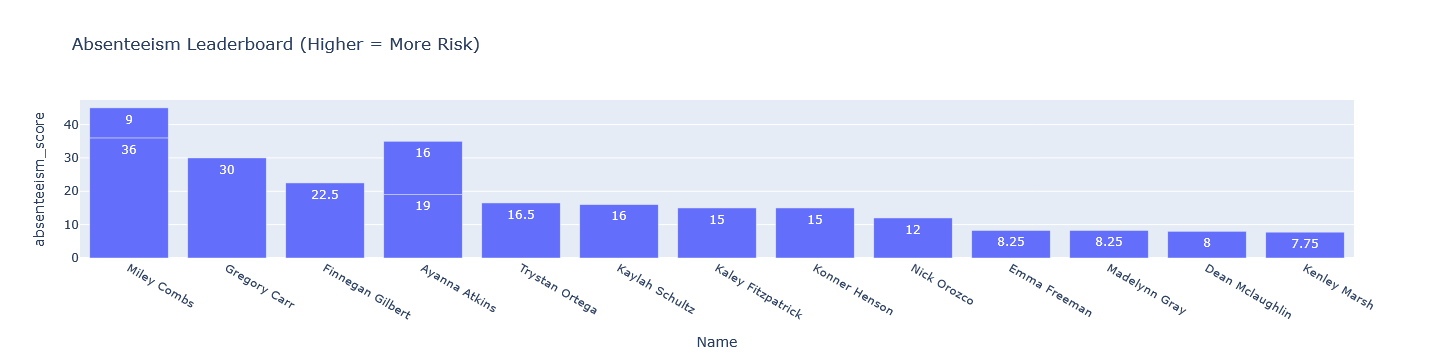

,Employee Code,Name,Month,attendance_rate,total_leaves,Leave without pay,absenteeism_score
71,Atq -372,Miley Combs,June 2022,0.40,12.00,12.00,36.00
221,Atq -485,Gregory Carr,Apr 2022,0.52,10.00,10.00,30.00
153,Atq -385,Finnegan Gilbert,May 2022,0.66,7.50,7.50,22.50
47,Atq -452,Ayanna Atkins,June 2022,0.50,6.50,5.50,19.00
24,Atq -349,Trystan Ortega,June 2022,0.50,5.50,5.50,16.50
95,Atq -419,Kaylah Schultz,May 2022,0.27,16.00,0.00,16.00
133,Atq -452,Ayanna Atkins,May 2022,0.70,6.50,1.00,16.00
70,Atq -374,Kaley Fitzpatrick,June 2022,0.77,5.00,5.00,15.00
152,Atq -387,Konner Henson,May 2022,0.77,5.00,5.00,15.00
139,Atq -408,Nick Orozco,May 2022,0.82,4.00,4.00,12.00


In [23]:
############################################################
## Dashboard – Absenteeism Risk
############################################################

risk_board = df.sort_values("absenteeism_score", ascending=False).head(15)

fig_abs = px.bar(
    risk_board,
    x="Name",
    y="absenteeism_score",
    title="Absenteeism Leaderboard (Higher = More Risk)",
    text="absenteeism_score"
)
fig_abs.show()

risk_board[[
    "Employee Code", "Name", "Month", "attendance_rate",
    "total_leaves", "Leave without pay", "absenteeism_score"
]]